# Amino acid diversity around CDR3 edges and independence from IGHV

In the paper we define the CDR3 as positions 95--102, extending one position beyond the Chothia CDR-H3 boundaries on each side to capture the variable part of the V(D)J junction. Two claims underpin this:

> While the IGHV gene templates part of the first codon or two of this region, the number of nucleotides trimmed during V(D)J recombination varies from rearrangement to rearrangement, so the amino acids at its start differ among antibodies carrying the same V allele.

> Unlike the CDR3 loop, the adjacent FR4 is a conserved framework segment that presents consistent selection pressure across antibodies, so it was retained despite also being J-gene-encoded.

This notebook checks both against the data, using MRCA parents (`depth == 2`) from the Rodriguez dataset under Chothia numbering.

## 1. Data loading

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import load_and_process_dnsm_data

MODEL_NAME = "dnsm_1m-v1jaffe+v1tang-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING = "chothia"
FR4_START = 103
MIN_OCCUPANCY = 0.25  # drop rare CDR3 insertion codes carried by few families

OUTPUT_DIR = f"_output/site_entropy/{NUMBERING}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 110

site_sub_probs_df, pcp_df = load_and_process_dnsm_data(
    model_name=MODEL_NAME,
    dataset_name=DATASET_NAME,
    numbering_scheme=NUMBERING,
)

mrca_idx = pcp_df.index[pcp_df.depth == 2]
site_df = site_sub_probs_df[site_sub_probs_df.pcp_index.isin(mrca_idx)]
n_mrca = site_df.pcp_index.nunique()
print(f"{n_mrca} MRCA parents, {site_df.site.nunique()} Chothia sites")

12939 MRCA parents, 148 Chothia sites


## 2. Shannon entropy of the parent amino acid at each site

In [2]:
def chothia_key(site):
    """Sort key handling insertion codes, e.g. 100A sorts after 100."""
    digits = "".join(c for c in site if c.isdigit())
    return (int(digits), "".join(c for c in site if c.isalpha()))


def shannon_entropy(values):
    p = values.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()


grouped = site_df.groupby("site")
entropy_df = pd.DataFrame(
    {
        "entropy": grouped.parent_aa.apply(shannon_entropy),
        "n": grouped.parent_aa.size(),
        "is_cdr": grouped.is_cdr.first(),
        "top_aa": grouped.parent_aa.apply(lambda s: s.mode().iat[0]),
        "top_frac": grouped.parent_aa.apply(lambda s: s.value_counts(normalize=True).iat[0]),
    }
).reset_index()

entropy_df["position"] = entropy_df.site.map(lambda s: chothia_key(s)[0])
entropy_df["is_fr4"] = entropy_df.position >= FR4_START
entropy_df = (
    entropy_df[entropy_df.n >= MIN_OCCUPANCY * n_mrca]
    .sort_values("site", key=lambda c: c.map(chothia_key))
    .reset_index(drop=True)
)
print(f"{len(entropy_df)} sites present in at least {MIN_OCCUPANCY:.0%} of MRCAs")

region_means = entropy_df.assign(
    region=np.select(
        [entropy_df.is_fr4, entropy_df.is_cdr], ["FR4", "CDR"], default="framework (1-94)"
    )
).groupby("region")[["entropy"]].agg(["mean", "min", "max"])
print(region_means.round(2))
entropy_df[entropy_df.position.between(92, 113)][["site", "n", "entropy", "top_aa", "top_frac"]].round(2)

124 sites present in at least 25% of MRCAs
                 entropy            
                    mean   min   max
region                              
CDR                 3.03  0.27  4.02
FR4                 0.35  0.01  1.51
framework (1-94)    1.18  0.00  3.76


,site,n,entropy,top_aa,top_frac
95,92,12939,0.00,C,1.00
96,93,12939,0.88,A,0.86
97,94,12939,1.80,R,0.68
98,95,12935,3.63,D,0.23
99,96,12897,4.02,G,0.14
100,97,12776,3.99,G,0.17
101,98,12685,3.99,G,0.17
102,99,12479,3.98,G,0.16
103,100,12081,3.98,G,0.15
104,100A,11182,3.97,G,0.15


## 3. Plot

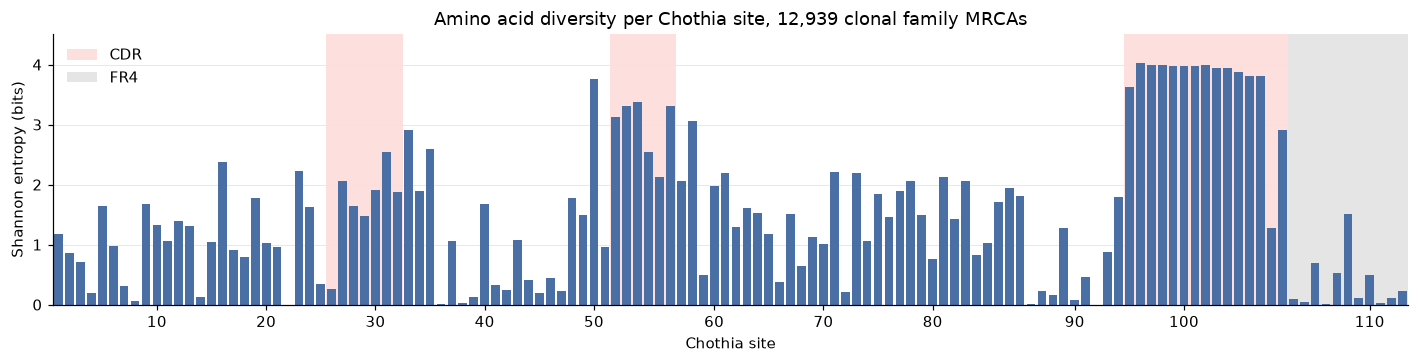

In [3]:
BAR = "#4a6fa5"
CDR_SHADE = "#fde0dd"
FR4_SHADE = "#e5e5e5"

fig, ax = plt.subplots(figsize=(13, 3.4))
x = np.arange(len(entropy_df))


def shade(mask, color, label):
    """Shade contiguous runs of sites where mask is True."""
    first = True
    starts = np.flatnonzero(mask & ~np.r_[False, mask[:-1]])
    ends = np.flatnonzero(mask & ~np.r_[mask[1:], False])
    for s, e in zip(starts, ends):
        ax.axvspan(s - 0.5, e + 0.5, color=color, lw=0, zorder=0,
                   label=label if first else None)
        first = False


shade(entropy_df.is_cdr.values, CDR_SHADE, "CDR")
shade(entropy_df.is_fr4.values, FR4_SHADE, "FR4")
ax.bar(x, entropy_df.entropy, width=0.8, color=BAR, lw=0, zorder=2)

ticks = [i for i, s in enumerate(entropy_df.site) if s.isdigit() and int(s) % 10 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels([entropy_df.site[i] for i in ticks])
ax.set_xlim(-0.5, len(entropy_df) - 0.5)
ax.set_ylim(0, entropy_df.entropy.max() * 1.12)
ax.set_xlabel("Chothia site")
ax.set_ylabel("Shannon entropy (bits)")
ax.set_title(f"Amino acid diversity per Chothia site, {n_mrca:,} clonal family MRCAs")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="0.9", lw=0.6, zorder=1)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/site_entropy.pdf")
fig.savefig(f"{OUTPUT_DIR}/site_entropy.png", dpi=200)
plt.show()

## 4. The same thing as a composition: what fraction of MRCAs carries each amino acid

Each bar sums to 100%, with one colour per amino acid. A site dominated by one residue shows
a single tall block; a site that is free to vary shows many thin ones.

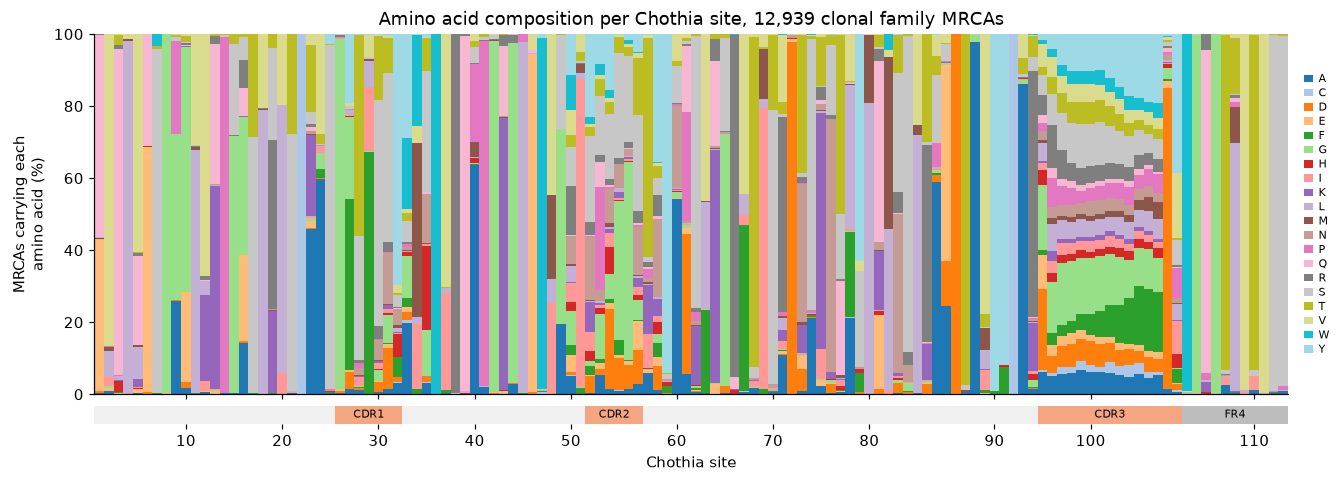

In [4]:
AAS = list("ACDEFGHIKLMNPQRSTVWY")
AA_COLOR = dict(zip(AAS, plt.get_cmap("tab20").colors))

order = {s: i for i, s in enumerate(entropy_df.site)}
comp = (
    site_df[site_df.site.isin(order)]
    .groupby("site")
    .parent_aa.value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .reindex(columns=AAS, fill_value=0.0)
)
comp = comp.loc[sorted(comp.index, key=chothia_key)] * 100
x = np.arange(len(comp))

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(14, 4.6), sharex=True,
    gridspec_kw={"height_ratios": [10, 0.5], "hspace": 0.06},
)
bottom = np.zeros(len(comp))
for aa in AAS:
    ax.bar(x, comp[aa], bottom=bottom, width=1.0, color=AA_COLOR[aa], lw=0, label=aa)
    bottom += comp[aa].values

ax.set_ylim(0, 100)
ax.set_ylabel("MRCAs carrying each\namino acid (%)")
ax.set_title(f"Amino acid composition per Chothia site, {n_mrca:,} clonal family MRCAs")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=1, fontsize=7, frameon=False, loc="center left",
          bbox_to_anchor=(1.005, 0.5), handlelength=0.9, handletextpad=0.5,
          labelspacing=0.25)

region_color = np.where(
    entropy_df.is_fr4, "#bdbdbd", np.where(entropy_df.is_cdr, "#f4a582", "#f0f0f0")
)
axr.bar(x, 1, width=1.0, color=region_color, lw=0)
axr.set_ylim(0, 1)
axr.set_yticks([])
axr.spines[:].set_visible(False)
for mask, name in [(entropy_df.is_cdr.values, "CDR"), (entropy_df.is_fr4.values, "FR4")]:
    starts = np.flatnonzero(mask & ~np.r_[False, mask[:-1]])
    ends = np.flatnonzero(mask & ~np.r_[mask[1:], False])
    for i, (s, e) in enumerate(zip(starts, ends)):
        axr.text((s + e) / 2, 0.5, f"{name}{i + 1}" if name == "CDR" else name,
                 ha="center", va="center", fontsize=7.5)

ticks = [i for i, s in enumerate(comp.index) if s.isdigit() and int(s) % 10 == 0]
axr.set_xticks(ticks)
axr.set_xticklabels([comp.index[i] for i in ticks])
axr.set_xlim(-0.5, len(comp) - 0.5)
axr.set_xlabel("Chothia site")

fig.savefig(f"{OUTPUT_DIR}/site_composition.pdf", bbox_inches="tight")
fig.savefig(f"{OUTPUT_DIR}/site_composition.png", dpi=200, bbox_inches="tight")
plt.show()